Google collab link : https://colab.research.google.com/drive/1YnYTegnSycO6kIikFwz9PfRWBskBIlXW?usp=sharing

#Problem : Help me find the factors influencing the people to purchace the term deposit plan.

#Goal : Find target customers.

Dataset link : https://archive.ics.uci.edu/dataset/222/bank+marketing

In [ ]:
import pandas as pd

df= pd.read_csv("/content/bank-full.csv", sep=';')

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df.shape

(45211, 17)

In [ ]:
purchased_by_job = df[df['y'] == 'yes']['job'].value_counts()
purchased_by_job

,count
job,
management,1301
technician,840
blue-collar,708
admin.,631
retired,516
services,369
student,269
unemployed,202
self-employed,187


In [ ]:
purchased_by_marital = df[df['y'] == 'yes']['marital'].value_counts()
purchased_by_marital

,count
marital,
married,2755
single,1912
divorced,622


In [ ]:
purchased_by_education = df[df['y'] == 'yes']['education'].value_counts()
purchased_by_education

,count
education,
secondary,2450
tertiary,1996
primary,591
unknown,252


In [ ]:
df_purchased = df[df['y'] == 'yes']

# Define age bins in multiples of 10
min_age = df_purchased['age'].min()
max_age = df_purchased['age'].max()
bins = list(range(0, max_age + 10, 10))

df_purchased['age_category'] = pd.cut(df_purchased['age'], bins=bins, right=False)

purchased_by_age_category = df_purchased['age_category'].value_counts().sort_index()
purchased_by_age_category

/tmp/ipykernel_1514/3778258312.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_purchased['age_category'] = pd.cut(df_purchased['age'], bins=bins, right=False)


,count
age_category,
"[0, 10)",0
"[10, 20)",18
"[20, 30)",910
"[30, 40)",1913
"[40, 50)",1063
"[50, 60)",785
"[60, 70)",365
"[70, 80)",180
"[80, 90)",48


In [ ]:
purchased_by_loan = df[df['y'] == 'yes']['loan'].value_counts()
purchased_by_loan

,count
loan,
no,4805
yes,484


In [ ]:
purchased_by_housing = df[df['y'] == 'yes']['housing'].value_counts()
purchased_by_housing

,count
housing,
no,3354
yes,1935


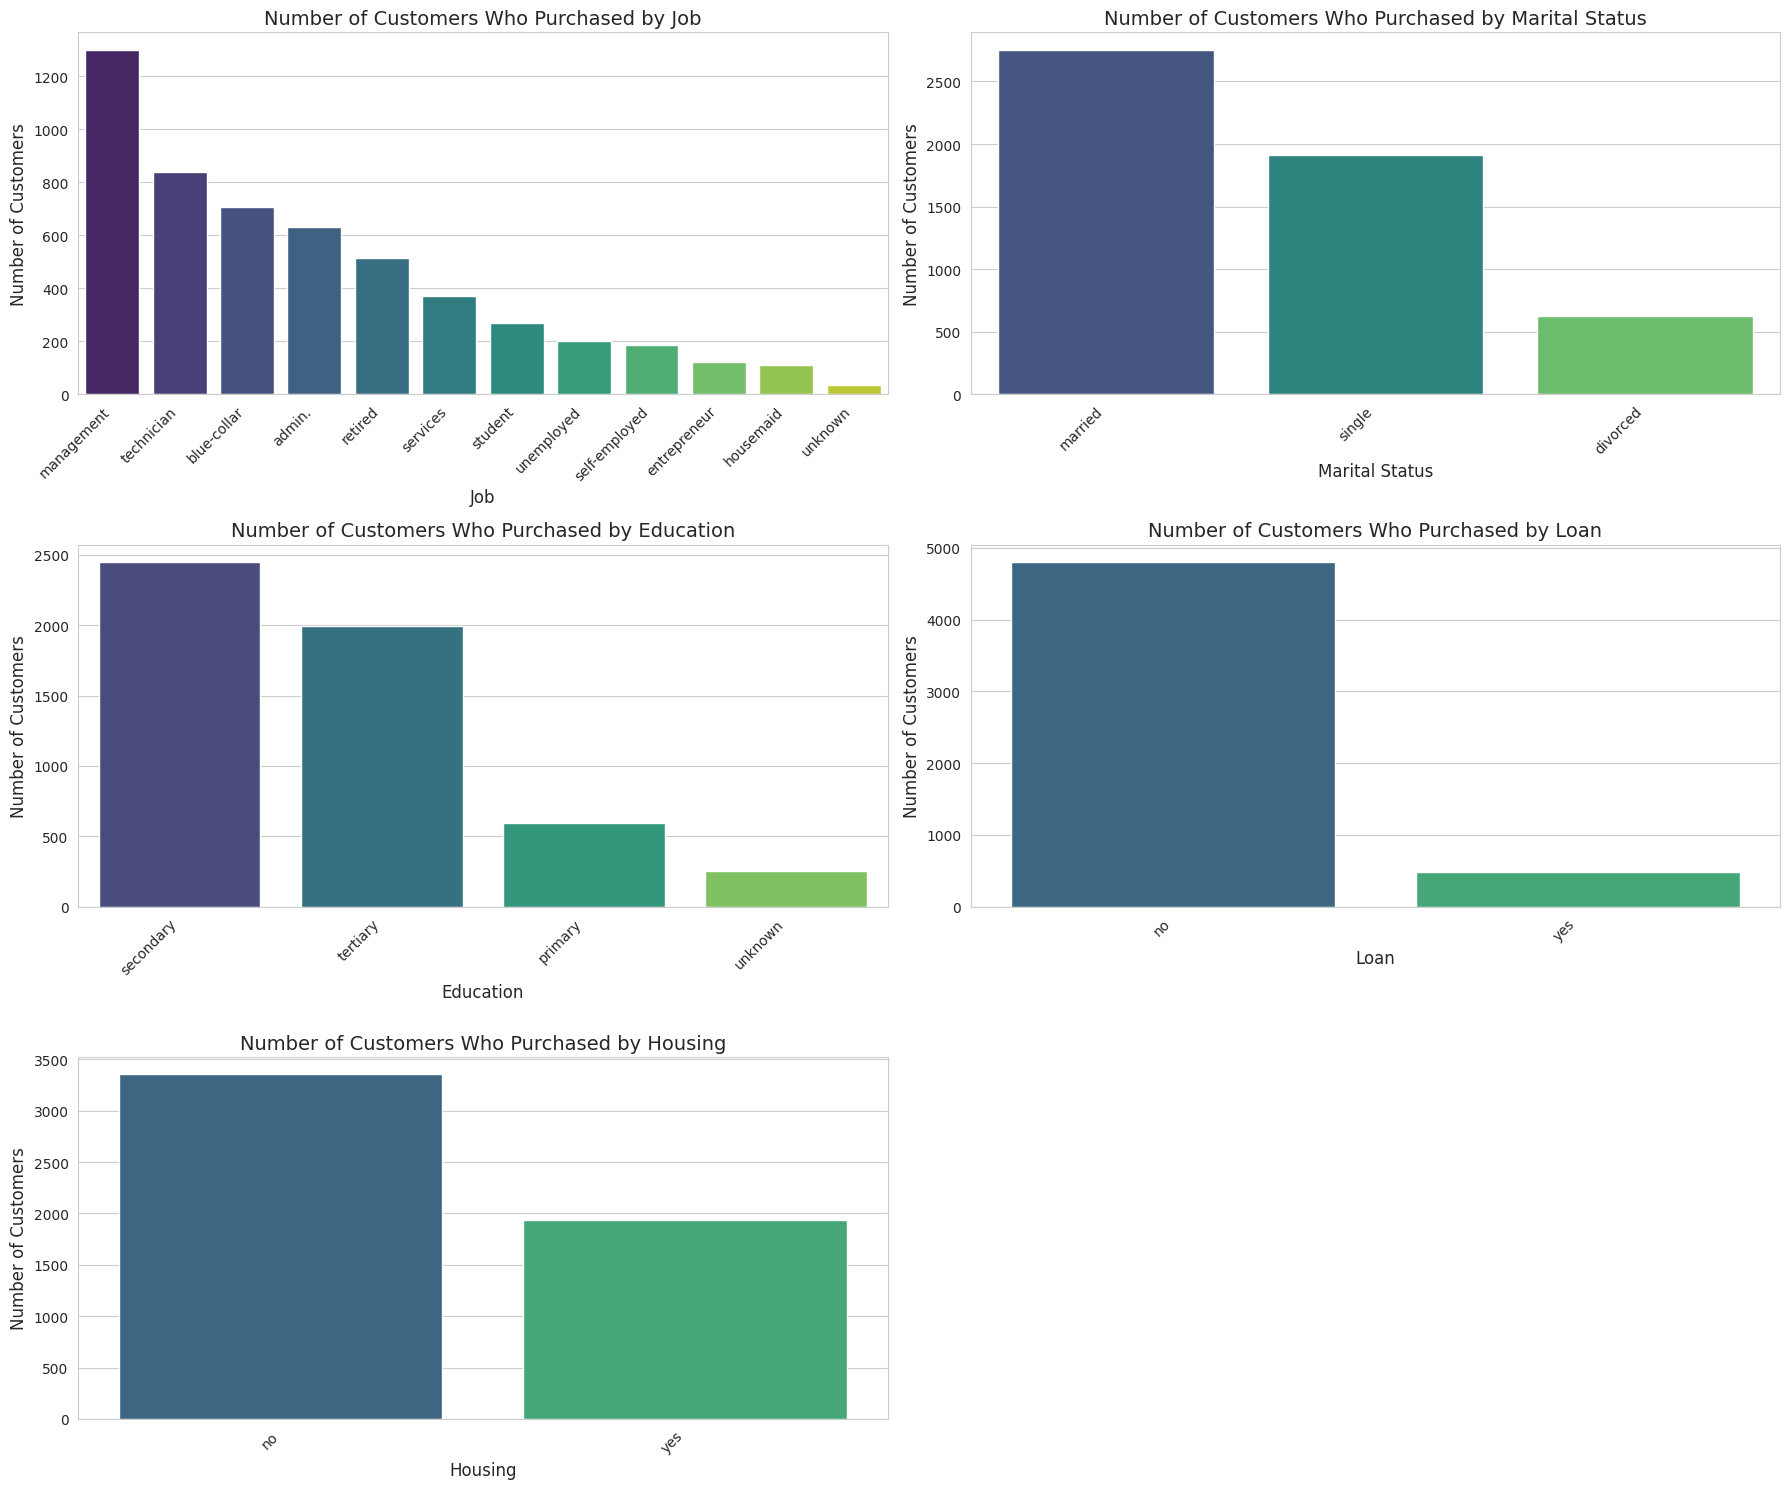

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

# List of categories to plot
categories = {
    "Job": purchased_by_job,
    "Marital Status": purchased_by_marital,
    "Education": purchased_by_education,
    "Loan": purchased_by_loan,
    "Housing": purchased_by_housing
}

# Create a figure to hold the subplots
plt.figure(figsize=(18, 15))

# Iterate through categories and create bar plots
for i, (title, data_series) in enumerate(categories.items()):
    plt.subplot(3, 2, i + 1) # Arrange plots in 3 rows, 2 columns
    sns.barplot(x=data_series.index, y=data_series.values, palette="viridis", hue=data_series.index, legend=False)
    plt.title(f'Number of Customers Who Purchased by {title}', fontsize=14)
    plt.xlabel(title, fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
#Understand Your Target Variable.
#The column y tells us if a customer subscribed to a term deposit ('yes' or 'no'). Let's see what the baseline conversion rate looks like.

# Check the distribution of the target variable
df['y'].value_counts()


,count
y,
no,39922
yes,5289


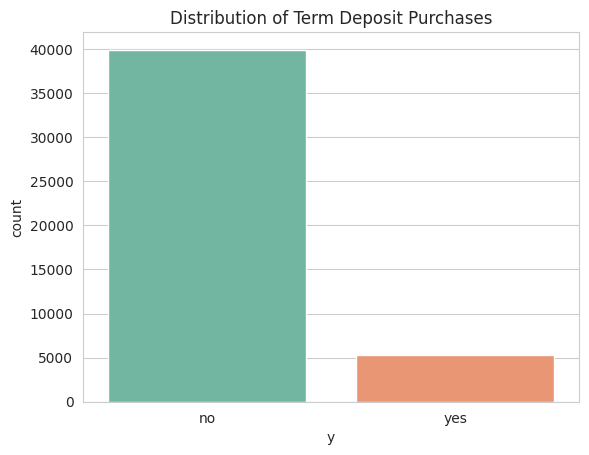

In [ ]:
# Visualize the conversion rate
sns.countplot(x='y', data=df, palette='Set2', hue='y', legend=False)
plt.title('Distribution of Term Deposit Purchases')
plt.show()

In [ ]:
# Calculate the exact conversion percentage
conversion_rate = (df['y'] == 'yes').mean() * 100
f"Overall conversion rate: {conversion_rate:.2f}%"

'Overall conversion rate: 11.70%'

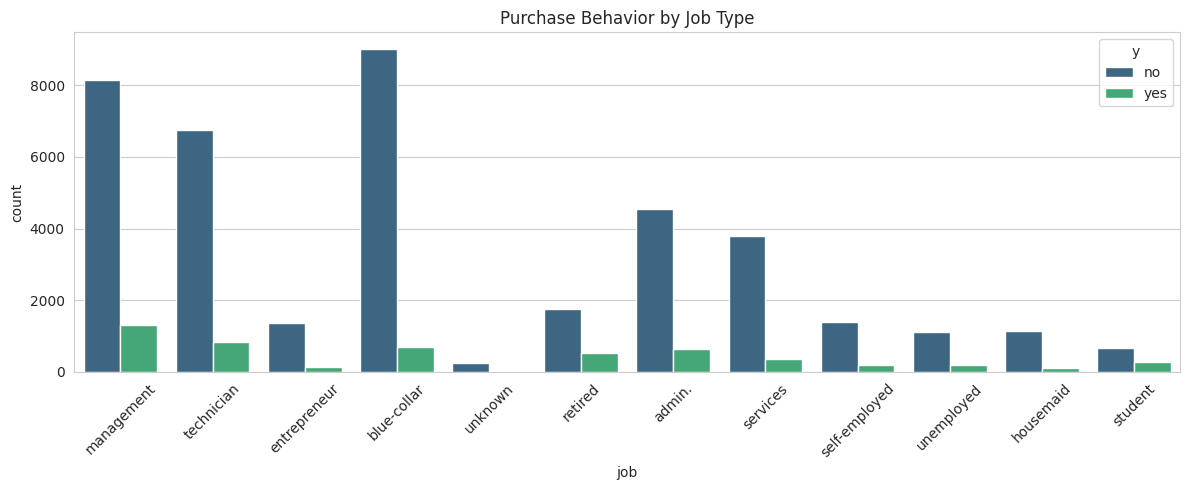

In [ ]:
#Job type Vs Subscription rate
plt.figure(figsize=(12, 5))
sns.countplot(x='job', hue='y', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Purchase Behavior by Job Type')
plt.tight_layout()
plt.show()

           age      balance
y                          
no   40.838986  1303.714969
yes  41.670070  1804.267915


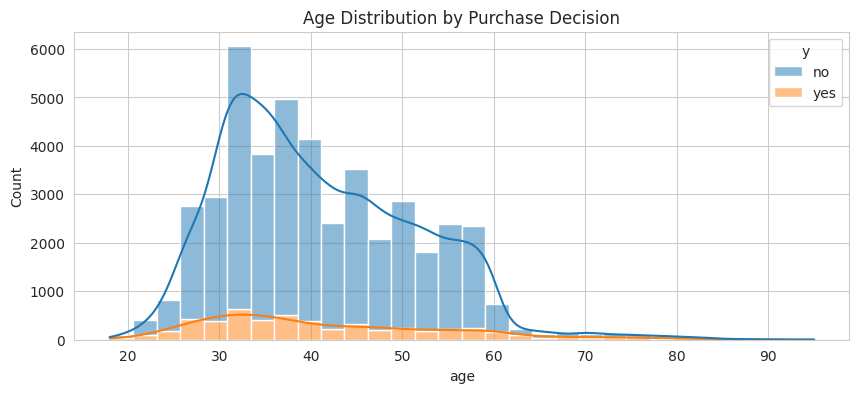

In [ ]:
#Balance & Age vs. Subscription

# Compare average balance and age for subscribers vs non-subscribers
print(df.groupby('y')[['age', 'balance']].mean())

# Visualize Age distribution based on subscription
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='age', hue='y', kde=True, multiple='stack', bins=30)
plt.title('Age Distribution by Purchase Decision')
plt.show()

In [ ]:
#Impact of Past Marketing Campaigns

# Does having a housing loan or personal loan hurt the chances?
pd.crosstab(df['housing'], df['y'], normalize='index') * 100
pd.crosstab(df['loan'], df['y'], normalize='index') * 100

y,no,yes
loan,,
no,87.344273,12.655727
yes,93.318609,6.681391


In [ ]:
# 1. Analyze historical campaign success (poutcome) vs current purchase
"--- Conversion Rate by Past Campaign Outcome ---"
poutcome_matrix = pd.crosstab(df['poutcome'], df['y'], normalize='index') * 100
poutcome_matrix

y,no,yes
poutcome,,
failure,87.390329,12.609671
other,83.315217,16.684783
success,35.274653,64.725347
unknown,90.838497,9.161503


In [ ]:
# 2. Analyze the power of communication length (duration)
"\n--- Average Call Duration (in seconds) ---"
avg_duration = df.groupby('y')['duration'].mean()
avg_duration

,duration
y,
no,221.182806
yes,537.294574


In [ ]:
# 3. Analyze seasonal impact (month) sorted by highest conversion rate
"\n--- Top Converting Months ---"
month_matrix = pd.crosstab(df['month'], df['y'], normalize='index') * 100
month_matrix.sort_values(by='yes', ascending=False)

y,no,yes
month,,
mar,48.008386,51.991614
dec,53.271028,46.728972
sep,53.540587,46.459413
oct,56.233062,43.766938
apr,80.320600,19.679400
feb,83.352208,16.647792
aug,88.986714,11.013286
jun,89.777195,10.222805
nov,89.848866,10.151134


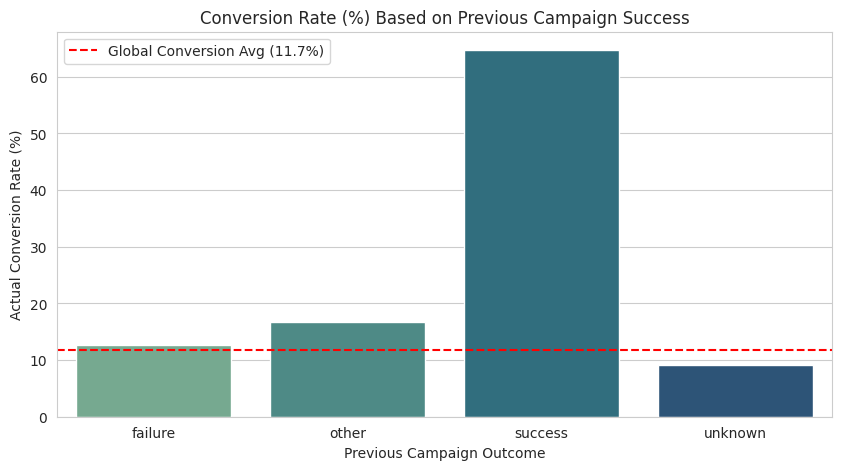

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=poutcome_matrix.index, y=poutcome_matrix['yes'], palette='crest',hue=poutcome_matrix.index,legend=False)
plt.title('Conversion Rate (%) Based on Previous Campaign Success')
plt.ylabel('Actual Conversion Rate (%)')
plt.xlabel('Previous Campaign Outcome')
plt.axhline(11.70, color='red', linestyle='--', label='Global Conversion Avg (11.7%)')
plt.legend()
plt.show()

# Executive Summary for Stakeholders

## 📌 Project Overview
The objective of this analysis was to discover the key empirical factors influencing customer enrollment in term deposit plans and establish an evidence-based **Target Customer Profile**. Using a dataset of 45,211 records with a baseline conversion rate of **11.70%**, we utilized advanced exploratory data analysis, segmented profiling, and cross-tabulation matrices to isolate high-yield consumer behaviors.

---

## 🔍 Key Data Insights

* **Past Success is the Strongest Predictor:**
  Customers who explicitly accepted proposals in previous marketing campaigns (`poutcome = success`) show an extraordinary current conversion rate of **64.73%**. Conversely, unknown historical backgrounds net a sub-par **9.16%** conversion rate.
* **Engagement Window Elasticity:**
  The depth of verbal communication directly correlates with conversion. Non-subscribers averaged calls of only **3.6 minutes** (221 seconds), whereas successful subscribers actively engaged for an average of **8.9 minutes** (537 seconds).
* **Significant Debt Backlash:**
  Clients carrying personal loan liabilities drop to a low **6.68%** conversion rate, while debt-free targets operate above average at **12.66%**.
* **Seasonal Micro-Trends:**
  Marketing communications executed in **March (51.99%)**, **December (46.73%)**, and **September (46.46%)** yield optimal, high-efficiency conversion rates compared to high-volume but low-return months like May (6.72%).

---

## 🎯 Target Customer Profile (TCP)

To optimize operational efficiency and maximize bank marketing ROI, marketing campaigns should explicitly prioritize clients matching this statistical benchmark:

| Metric / Dimension | Optimal Target Customer Persona |
| :--- | :--- |
| **Financial Health Profile** | High yearly balance balance (> \$1,800); Zero active personal/housing loans |
| **Demographic Core** | Retired individuals, Students, and Senior Management |
| **Historical Relationship** | Clients previously classified under a 'Success' campaign outcome |
| **Campaign Timing Strategy** | Prioritize scheduling outreach cycles during March, September, and December |

---

## 🚀 Strategic Recommendations

1. **Implement Pre-Call Financial Filtering:** Restructure CRM operations to automatically prioritize debt-free accounts holding higher cash balances to limit wasted outbound dials.
2. **Revamp Communication Frameworks:** Train call agents on relationship-building strategies rather than rapid pitches, explicitly aiming to extend conversational call duration past the critical 5-minute inflection point.
3. **Temporal Campaign Balancing:** Shift aggressive marketing spend away from low-yield seasonal windows (like May) and reallocate budgets toward highly responsive quarters (March/September/December).